In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [2]:
import sys
import os

# Add the project root (one level up from 'scripts/') to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
print(project_root)
if project_root not in sys.path:
    sys.path.append(project_root)

from utils import utils

C:\Users\Or Shkuri\PycharmProjects\MissingFeatures


## Using the preprocessed dataset

In [15]:
# dataset_name = 'Statlog (German Credit Data)'
# # Load data
# data_path = "../../data"
# train_set = pd.read_csv(f"{data_path}/{dataset_name}/train/data.csv")
# X_train, y_train, X_val, y_val = utils.preprocess_split(train_set)

# X = pd.concat([X_train, X_val])
# # y = pd.concat([y_train, y_val])
# X.iloc[:, list(range(22))].head()

## Using the actual dataset

In [20]:
dataset_name = 'Statlog (German Credit Data)'
data_path = f"../../datasets/{dataset_name}/german.data-numeric"
df = pd.read_csv(data_path, header=None, sep='\s+')
df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       1000 non-null   int64
 1   1       1000 non-null   int64
 2   2       1000 non-null   int64
 3   3       1000 non-null   int64
 4   4       1000 non-null   int64
 5   5       1000 non-null   int64
 6   6       1000 non-null   int64
 7   7       1000 non-null   int64
 8   8       1000 non-null   int64
 9   9       1000 non-null   int64
 10  10      1000 non-null   int64
 11  11      1000 non-null   int64
 12  12      1000 non-null   int64
 13  13      1000 non-null   int64
 14  14      1000 non-null   int64
 15  15      1000 non-null   int64
 16  16      1000 non-null   int64
 17  17      1000 non-null   int64
 18  18      1000 non-null   int64
 19  19      1000 non-null   int64
 20  20      1000 non-null   int64
 21  21      1000 non-null   int64
 22  22      1000 non-null   int64
 23  23      1000 n

### Check missing values

In [22]:
pd.DataFrame({'total_missing': df.isnull().sum()}).sum()

total_missing    0
dtype: int64

### Statistics of features

In [23]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,32.711000,2.105000,3.384000,2.68200,2.845000,2.358000,35.546000,...,0.234000,0.103000,0.907000,0.041000,0.179000,0.713000,0.022000,0.2000,0.630000,1.300000
std,1.257638,12.058814,1.08312,28.252605,1.580023,1.208306,0.70808,1.103718,1.050209,11.375469,...,0.423584,0.304111,0.290578,0.198389,0.383544,0.452588,0.146757,0.4002,0.483046,0.458487
min,1.000000,4.000000,0.00000,2.000000,1.000000,1.000000,1.00000,1.000000,1.000000,19.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,1.000000
25%,1.000000,12.000000,2.00000,14.000000,1.000000,3.000000,2.00000,2.000000,1.000000,27.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,1.000000
50%,2.000000,18.000000,2.00000,23.000000,1.000000,3.000000,3.00000,3.000000,2.000000,33.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000,1.000000
75%,4.000000,24.000000,4.00000,40.000000,3.000000,5.000000,3.00000,4.000000,3.000000,42.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000,2.000000
max,4.000000,72.000000,4.00000,184.000000,5.000000,5.000000,4.00000,4.000000,4.000000,75.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,2.000000


### Plot numerical features

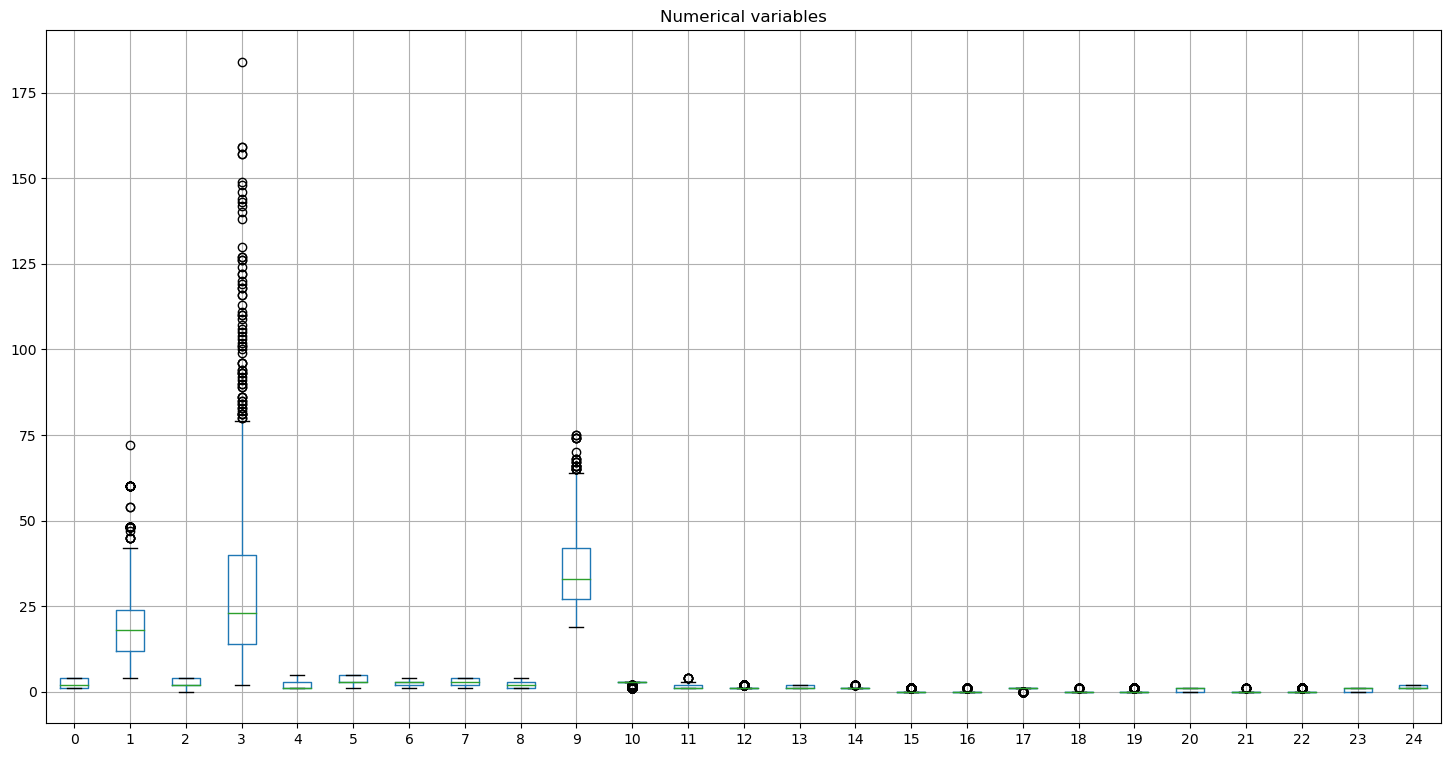

In [24]:
plt.figure(figsize=(18, 9))
columns = list(df.columns)
df.boxplot()
plt.title("Numerical variables")
plt.show()

We can observe that features have different scaling.

### Understand distribution of features

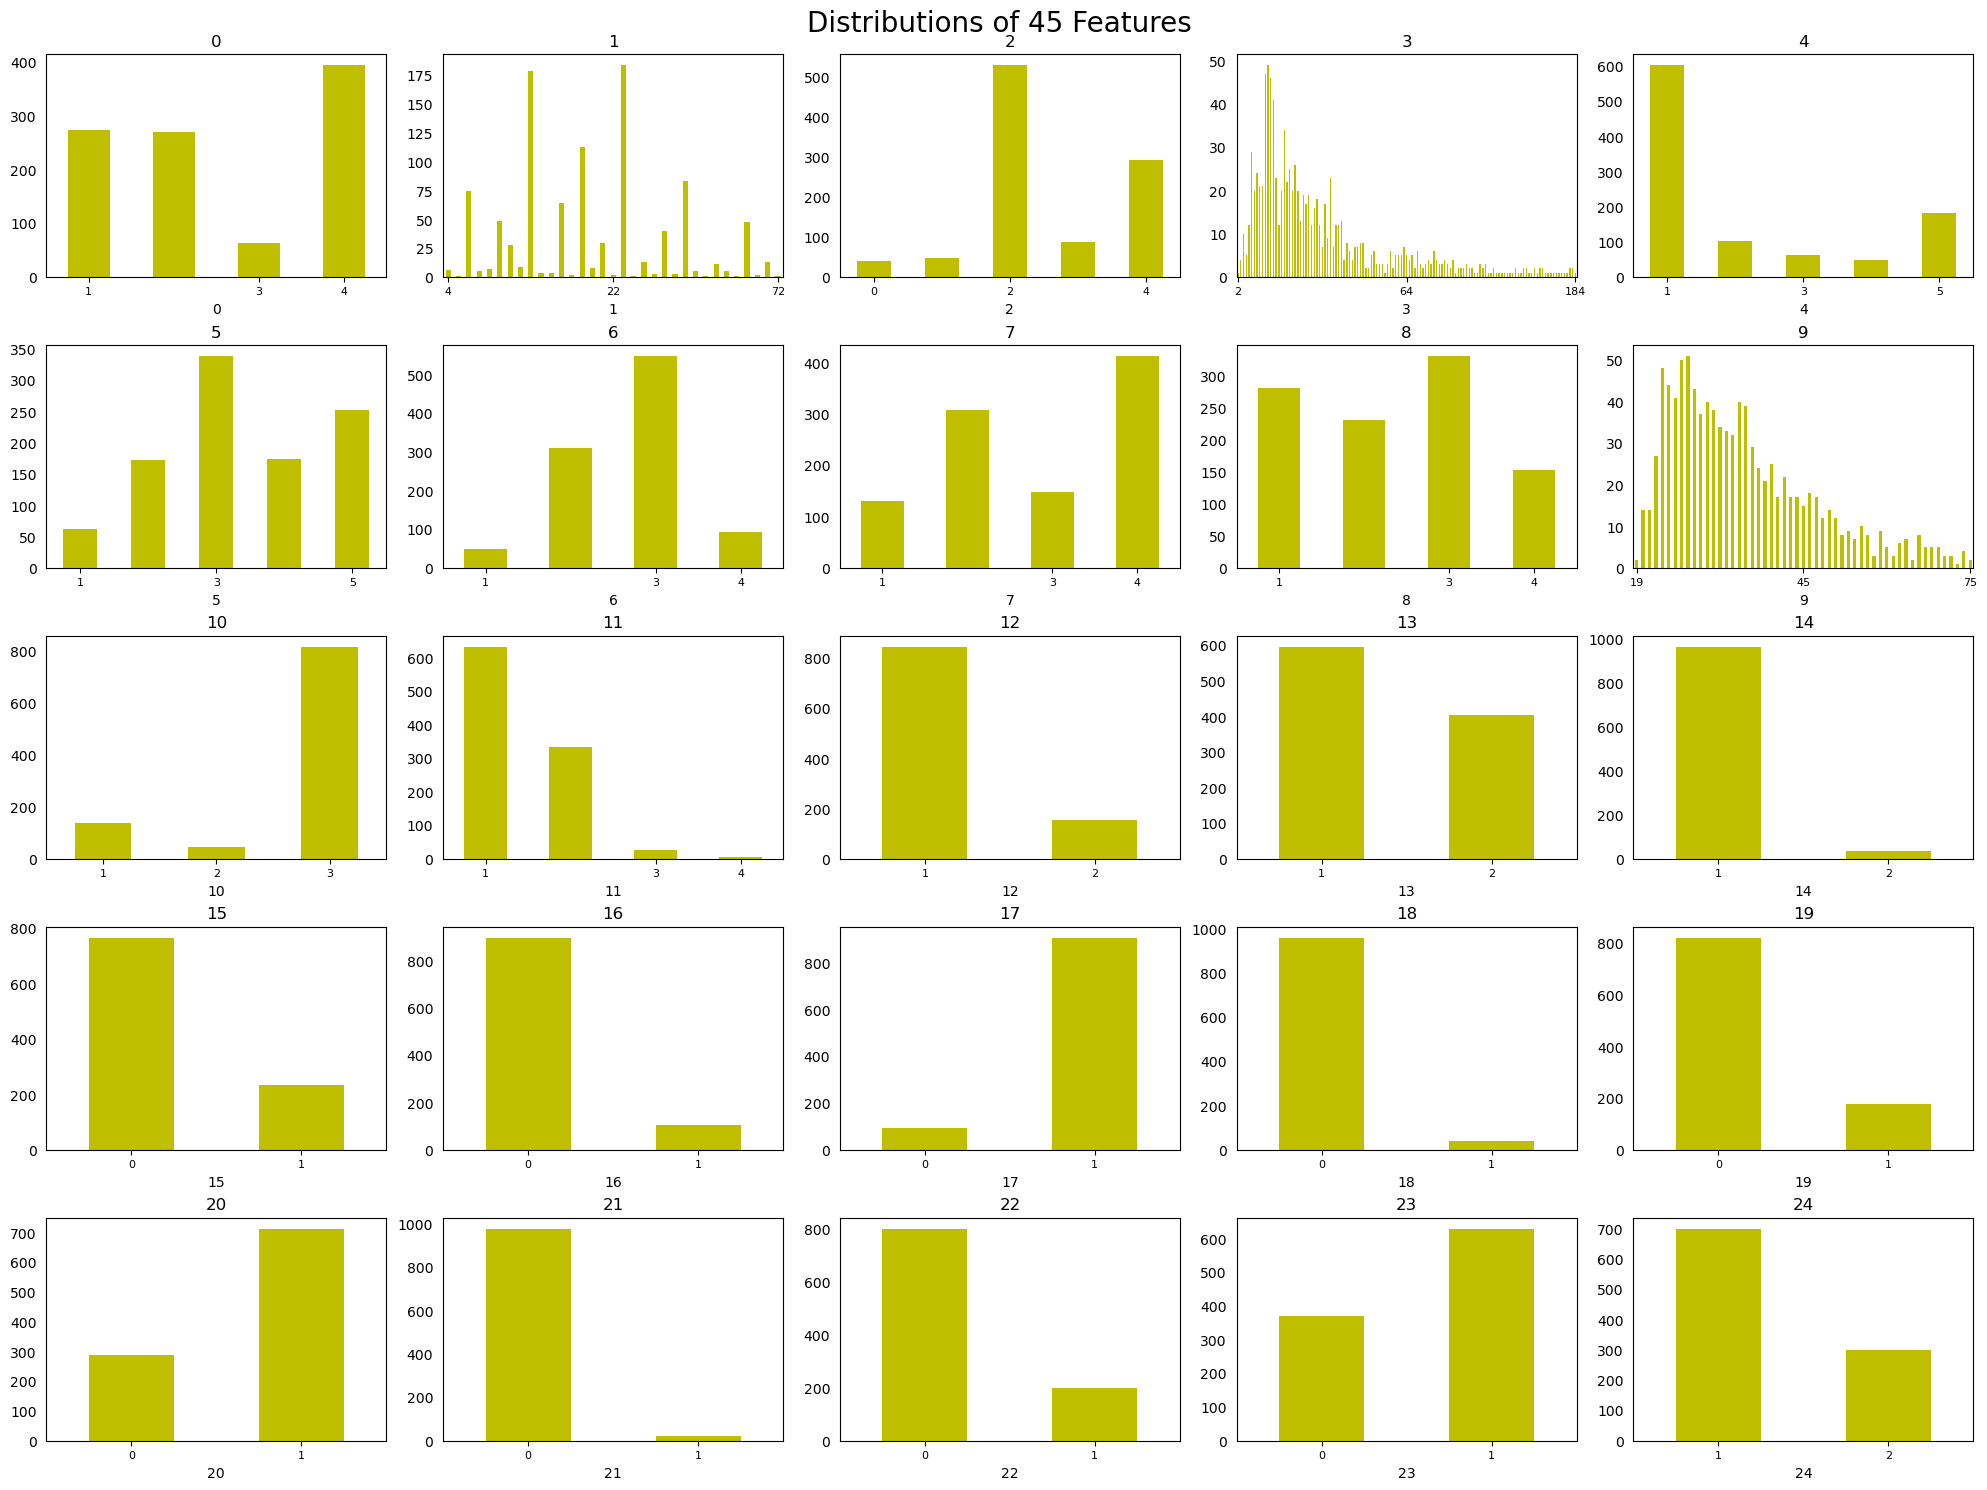

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dist(col, ax):
    counts = df[col].dropna().value_counts().sort_index()
    counts.plot(kind='bar', color='y', ax=ax)

    ax.set_xlabel(col, fontsize=10)
    ax.set_title(f"{col}", fontsize=12)

    num_bars = len(counts)
    if num_bars > 3:
        positions = [0, num_bars // 2, num_bars - 1]
        labels = [str(counts.index[pos]) for pos in positions]
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=0, fontsize=8)
    else:
        ax.set_xticklabels(counts.index, rotation=0, fontsize=8)

    # Optional: reduce y-axis ticks clutter
    ax.yaxis.set_ticks_position('none') 
    return ax

num_features = 25
cols = list(df.columns)[:num_features]

rows, cols_per_row = 5, 5
fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row*4, rows*3))
fig.tight_layout(h_pad=3, w_pad=1)
fig.subplots_adjust(top=0.95)

for i, ax in enumerate(axes.flat):
    if i < num_features:
        plot_dist(cols[i], ax)
    else:
        ax.axis('off')  # turn off unused subplots

fig.suptitle("Distributions of 45 Features", fontsize=20)
plt.show()


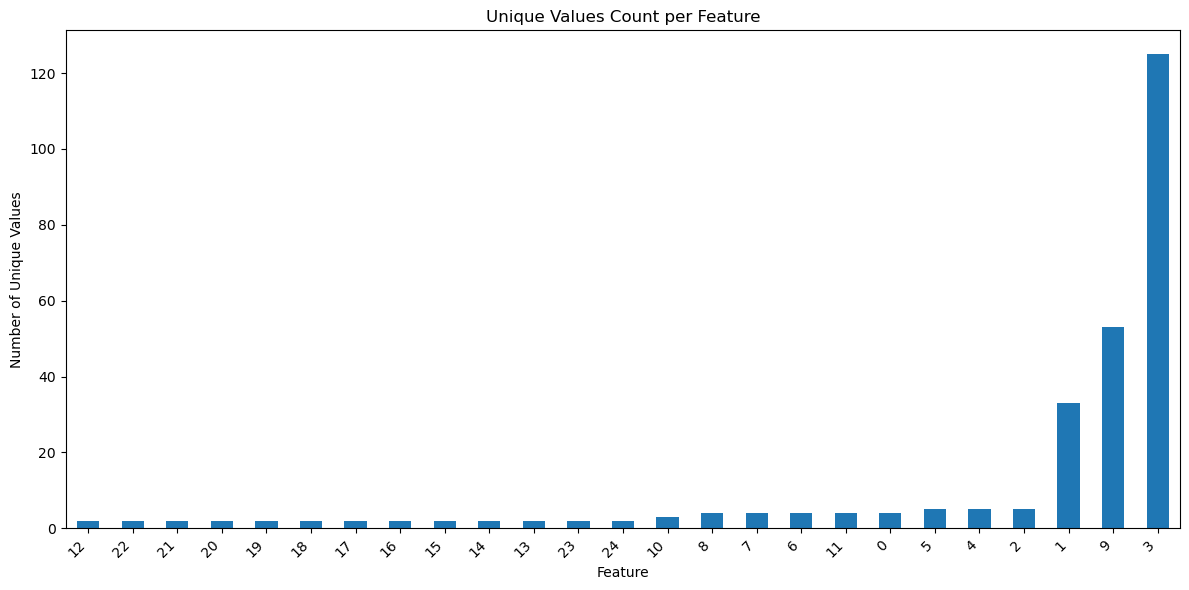

In [27]:
uniques_df = pd.DataFrame(index=df.columns, columns=['count'])
for col in df.columns:
    uniques_df.loc[col, :] = df.loc[:, col].nunique()

uniques_df = uniques_df.sort_values(by='count')

plt.figure(figsize=(12, 6))
uniques_df['count'].plot(kind='bar')
plt.xlabel('Feature')
plt.ylabel('Number of Unique Values')
plt.title('Unique Values Count per Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
# df_reset = df.reset_index(drop=True)
categoricals_amount = len(uniques_df[uniques_df['count']<20])
cont_amount = len(uniques_df[uniques_df['count']>=20])

print(f"Amount of features with less than 20 uniques: {categoricals_amount}")
print(f"Amount of features with more than 20 uniques: {cont_amount}")

Amount of features with less than 20 uniques: 22
Amount of features with more than 20 uniques: 3


In [32]:
categorical_features = list(uniques_df[uniques_df['count']<20].index)
cont_features = list(uniques_df[uniques_df['count']>=20].index)

### Understand correlation between cont features

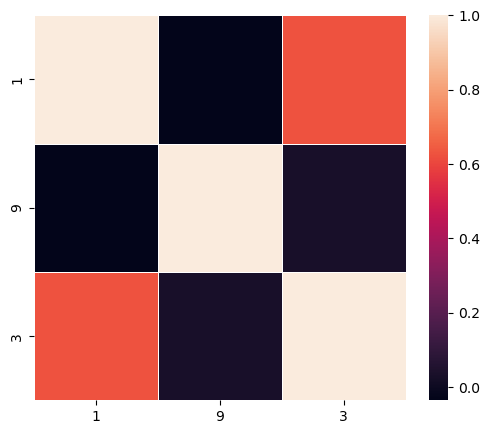

In [31]:
corr = df.loc[:, cont_features].corr(method = 'pearson')
plt.figure(figsize=(6,5))
sns.heatmap(corr,annot=False,fmt=".2f", linewidth=.5)
plt.show()

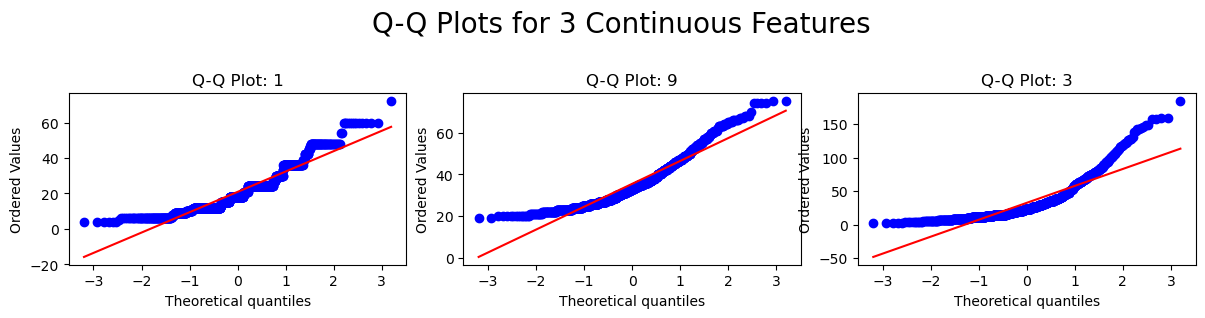

In [39]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# cont_features: list of feature names with >=20 unique values
# Example:
# cont_features = list(uniques_df[uniques_df['count'] >= 20].index)

num_features = len(cont_features)
rows, cols_per_row = 1, 3  # adjust if needed

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3))
fig.tight_layout(h_pad=3, w_pad=1)
fig.subplots_adjust(top=0.7)

for i, ax in enumerate(axes.flat):
    if i < num_features:
        feature = cont_features[i]
        data = df[feature].dropna()
        stats.probplot(data, dist="norm", plot=ax)
        ax.set_title(f"Q-Q Plot: {feature}", fontsize=12)
    else:
        ax.axis('off')  # Hide unused subplots

fig.suptitle(f"Q-Q Plots for {num_features} Continuous Features", fontsize=20)
plt.show()
